In [1]:
!pip install transformers
!pip install torch
!pip install pillow

In [2]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch

In [4]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [6]:
from google.colab import files
files.upload()


Saving dog.jpg to dog.jpg


{'dog.jpg': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04\xb0\x00\x00\x04\xb0\x08\x03\x00\x00\x00\xdc\xffC\xfd\x00\x00\x02(PLTE\x00\x00\x00\xcb\xc4\xc3\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff?\x16\x0eO)!D\x19\x10I\x1b\x11J\x1a\x0fQ\x1c\x10lH3g"\rf,\x18y0\x16s9#\x89?#\x8dM)\x836\x1aw*\x10q\x1e\x08q&\r\x910\x10\x84,\x10Y%\x14O\x14\x08\x84$\n{#\ny\x1b\x07q\x16\x0bi\x13\x08j\x1b\x07\x9d:\x14\xa1B\x1b\x97^4\xa9U3_\x1a\x08A(\x18_\x0f\x05~"\x1f\x9fI+\xc4XE\xb1tE\xd1pT\xd8\x91Y\xfa\xb4\xaa\xf8\xc3\x85\xf4\xbeu\xfa\xc1p\xf1\xb9p\xef\xb2i\xe9\xa8g\xe7\xa2]\xc4\x86SR7%\xf9\xb9k\xec\xadh\xe3\x9bZ\xd4\x81C\xf8\xb5f\xf8\xc4y\xf0\xb5k\xf8\xbce\xf7\xb9c\xf9\xc0i\xfd\xc5p\x9bk?\x8f)\x0b\xbb\\0\xe2\x8c\x84\xfd\xc8t\xab\x9e\x8d\xfa\xcc\x86\xfd\xccz\xfd\xd0\x81\xfe\xd6\x8b\xfe\xdb\x99\xe9\xc3\x92\xfd\xde\xa2\xf2\xb0Z\xef\xabX\xc7l5\xff\xff\xff\xe1\x8aN\xed\xa9U\xec\xa4Q\xe9\x9fN\xe4\x94N\xf7\xb8a\xf7\xb2c\xee\xa4T\xdf\x83D\xdf{x\xf4\xb6`\xf6\xb5^\xf1\xa8S\xf1\xadY\xf4\xb4]\xe5\x97I\xe0\x8dA\xd

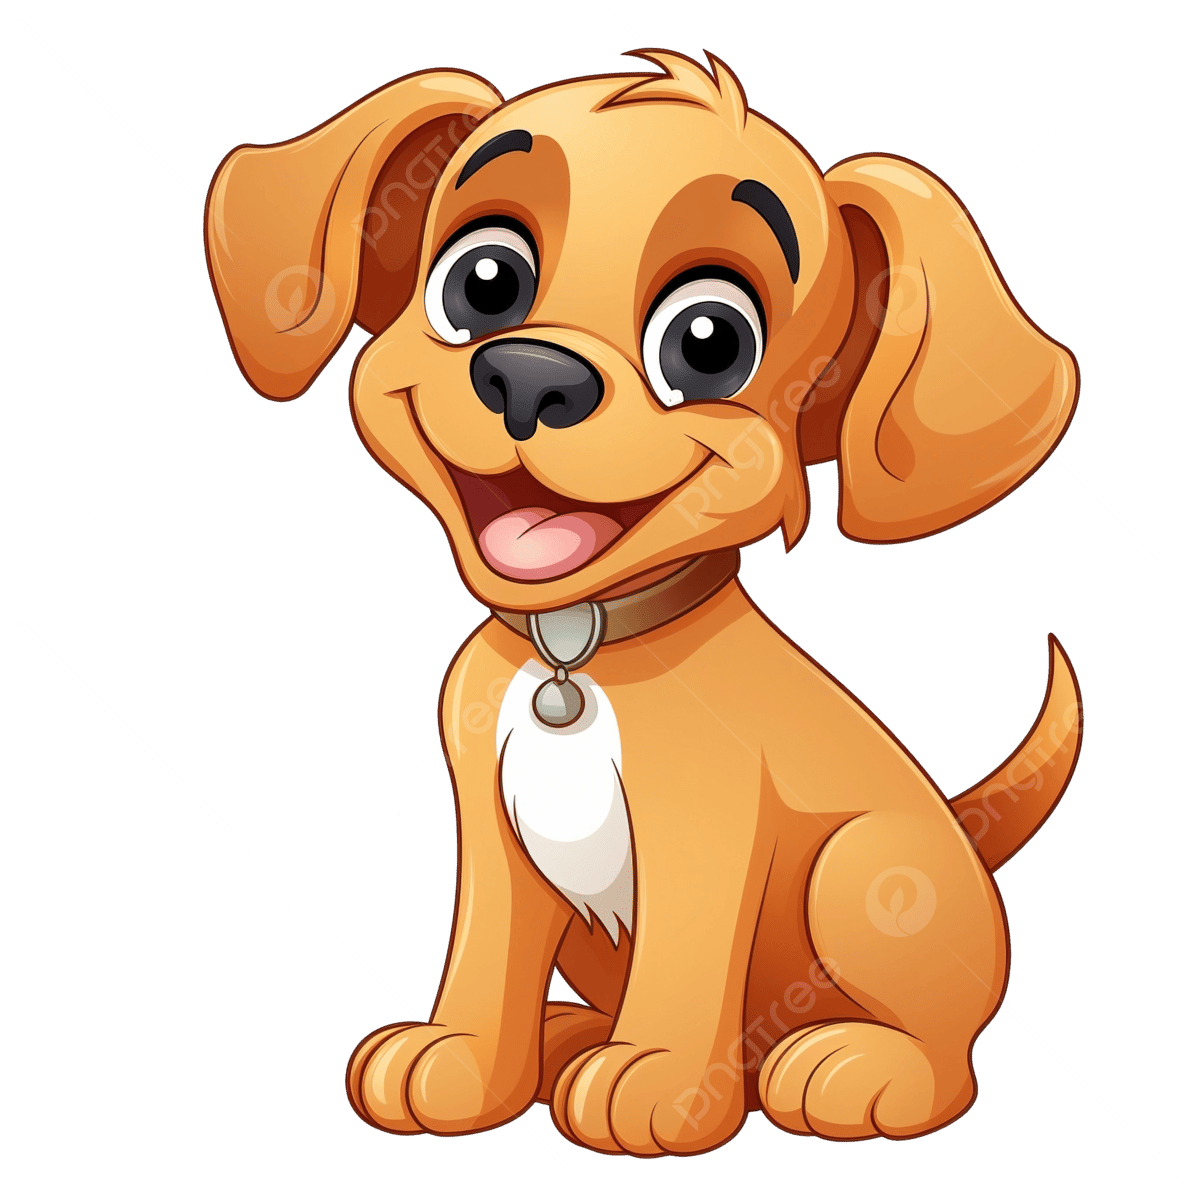

In [8]:
image = Image.open("dog.jpg")
image

In [9]:
texts = ["a dog","a cat","a person"]

In [10]:
inputs = processor(
    text=texts,
    images=image,
    return_tensors="pt",
    padding=True
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [11]:
outputs = model(**inputs)

In [12]:
logits_per_image=outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)
print(probs)

tensor([[0.9853, 0.0047, 0.0100]], grad_fn=<SoftmaxBackward0>)
